# 淘宝用户行为深度分析与增长策略实战

## 一、环境配置与数据加载

In [1]:
! pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pandas-3.0.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.3 MB 8.2 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.3 MB 9.9 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.3 MB 10.2 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.3 MB 10.4 MB/s eta 0:00:01
   -------------------------------------- - 8.9/9.3 MB 8.9 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 8.1 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------------------------- ------------- 1.6/2.3 MB 6.5 MB/s eta 0:00:01
   ----------------------------------- ---- 2.1/2.3 MB 5.3 MB/s eta 0:00:

In [2]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体和负号显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 20)

In [3]:
df = pd.read_csv(r'C:\Users\63546\Desktop\实战项目\淘宝用户行为数据分析\2017年淘宝用户行为数据.csv' ,
                 skiprows=1,
                 names=['user_id','item_id','item_category','behavior_type','timestamp'])
print(df.head(5))
print(df.info())

   user_id  item_id  item_category behavior_type   timestamp
0        1  2268318        2520377            pv  1511544070
1      100  2337874        1194311            pv  1511742199
2      100  4492008        4482016            pv  1511766135
3      100   251391        3738615            pv  1511929658
4      100  1203280        4640311            pv  1512123340
<class 'pandas.DataFrame'>
RangeIndex: 2003017 entries, 0 to 2003016
Data columns (total 5 columns):
 #   Column         Dtype
---  ------         -----
 0   user_id        int64
 1   item_id        int64
 2   item_category  int64
 3   behavior_type  str  
 4   timestamp      int64
dtypes: int64(4), str(1)
memory usage: 76.4 MB
None


In [4]:
print("行为类型分布:")
print(df['behavior_type'].value_counts())

行为类型分布:
behavior_type
pv      1794016
cart     111081
fav       57668
buy       40252
Name: count, dtype: int64


## 二、数据清洗与预处理

### 1.检查缺失值

In [5]:
print("缺失值情况:")
print(df.isnull().sum())

缺失值情况:
user_id          0
item_id          0
item_category    0
behavior_type    0
timestamp        0
dtype: int64


由上可知，该数据集不存在缺失值

### 2.数据去重

In [6]:
# 检查重复值
print("检查重复值:")
print(df.duplicated(keep='first').sum())

# 去重
df.drop_duplicates(inplace=True)

检查重复值:
0


### 3.提取时间特征

In [7]:
# 转换数据类型
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s', utc=True).dt.tz_convert('Asia/Shanghai').dt.tz_localize(None)

# 提取时间特征
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.day_name()
print(df.head())

# 查看日期范围
min_date = df['datetime'].min()
max_date = df['datetime'].max()
print(f"日期范围: {min_date} - {max_date}")

   user_id  item_id  item_category behavior_type   timestamp  \
0        1  2268318        2520377            pv  1511544070   
1      100  2337874        1194311            pv  1511742199   
2      100  4492008        4482016            pv  1511766135   
3      100   251391        3738615            pv  1511929658   
4      100  1203280        4640311            pv  1512123340   

             datetime        date  hour    weekday  
0 2017-11-25 01:21:10  2017-11-25     1   Saturday  
1 2017-11-27 08:23:19  2017-11-27     8     Monday  
2 2017-11-27 15:02:15  2017-11-27    15     Monday  
3 2017-11-29 12:27:38  2017-11-29    12  Wednesday  
4 2017-12-01 18:15:40  2017-12-01    18     Friday  
日期范围: 1905-07-13 22:14:23 - 2036-10-22 23:25:08


时间戳转换：将 timestamp列 时间戳转换为可读的日期时间格式 datetime列 。  
特征提取：从时间中提取“小时”、“星期”等维度，为时间序列分析做准备。  
异常值处理：过滤非目标时间段的数据，确保分析窗口统一。

### 4.设置行为权重
为用户行为赋予权重值，便于后续的行为得分计算

权重设计：购买(4) > 加购(3) > 收藏(2) > 浏览(1)

In [8]:
# 处理行为类型
behavior_map = {'pv': 1, 'buy': 4, 'cart': 3, 'fav': 2}
df['behavior_weight'] = df['behavior_type'].map(behavior_map)

## 5.过滤日期异常值

这份阿里公开淘宝用户行为数据集的时间范围为：2017-11-25 ~ 2017-12-03，一共9天

In [9]:
# 筛选出所需的日期范围，过滤日期异常值：
import datetime
start_day = datetime.date(2017,11,25)
end_day = datetime.date(2017,12,3)
df = df[(df['date']>=start_day) & (df['date']<=end_day)]

# 时间跨度
print(f"时间跨度：{(end_day-start_day).days+1}天")

时间跨度：9天


## 三、探索性数据分析（EDA）

### 1.数据分布情况

总用户数: 711902
总商品数: 746948
总品类数: 7020
behavior_type
pv      1792891
cart     111081
fav       57668
buy       40252
Name: count, dtype: int64


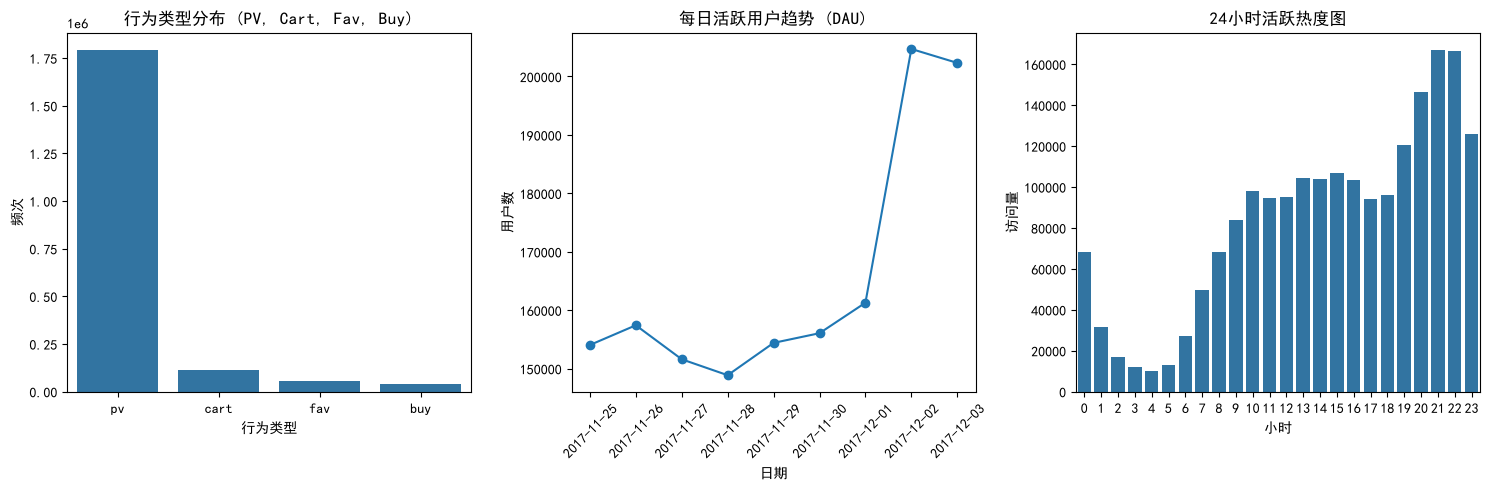

In [10]:
# 1.1 总体规模（整体数据概览）
total_users = df['user_id'].nunique()
total_items = df['item_id'].nunique()
total_categories = df['item_category'].nunique()
print(f"总用户数: {total_users}")
print(f"总商品数: {total_items}")
print(f"总品类数: {total_categories}")

# 1.2 行为分布分析
behavior_counts = df['behavior_type'].value_counts().reindex(['pv', 'cart', 'fav', 'buy'])
print(behavior_counts)

# 1.3 可视化
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.countplot(data=df, x='behavior_type', order=['pv', 'cart', 'fav', 'buy'])
plt.title('行为类型分布 (PV, Cart, Fav, Buy)')
plt.xlabel('行为类型')
plt.ylabel('频次')

plt.subplot(1, 3, 2)

# 1.4 日活跃用户趋势
daily_active = df.groupby('date')['user_id'].nunique()
plt.plot(daily_active.index, daily_active.values, marker='o')
plt.title('每日活跃用户趋势 (DAU)')
plt.xlabel('日期')
plt.ylabel('用户数')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)

# 1.5 小时活跃分布
hourly_active = df.groupby('hour')['user_id'].count()
sns.barplot(x=hourly_active.index, y=hourly_active.values)
plt.title('24小时活跃热度图')
plt.xlabel('小时')
plt.ylabel('访问量')

plt.tight_layout()
plt.show()

根据上图发现：用户行为主要分布在浏览上，而且用户在12月2日和12月3日(周六和周日)活跃度高涨，同时，在一天之中，晚上的活跃度更高

### 2.定义时间切片
接下来分析为什么会有以上现象，即用户在12月2日和12月3日活跃度高涨的现象  
猜测：可能和周末或者“双12”有关，根据历史电商大促规律，12月2-3日极大概率是“双12”预售期或“双旦”预热期  
因此下面将数据分为三类：工作日(Weekday)、周末(Weekend)、大促预热日(Promotion)

              period      UV      人均浏览     加购收藏率       转化率
0  大促预热期 (12.2-12.3)  351696  1.396979  0.095862  0.020897
1               普通周末  271778  1.392184  0.093307  0.021699


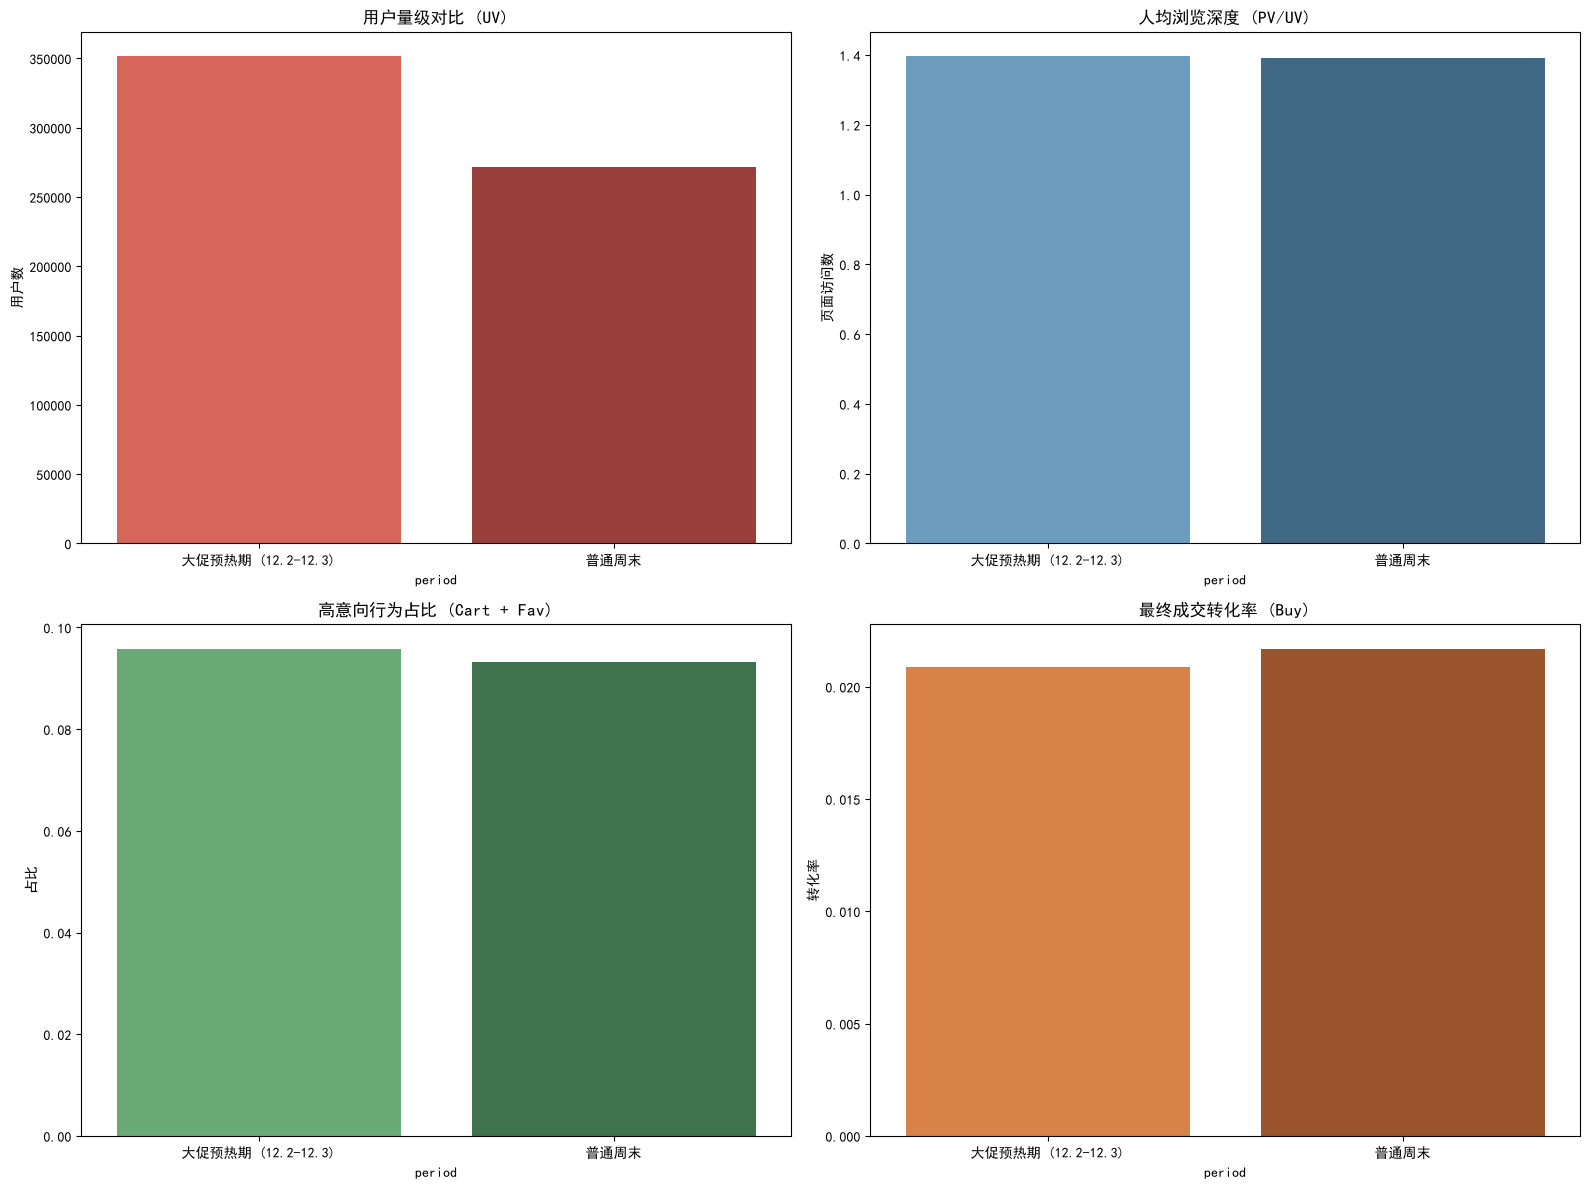

In [11]:
# 2.1 创建日期分类器
def classify_date(row):
    date = row['date']
    if date == datetime.date(2017, 12, 2) or date == datetime.date(2017, 12, 3):
        return '大促预热期 (12.2-12.3)'
    elif date.weekday() < 5: # 周一至周五
        return '工作日'
    else: # 周六、周日
        return '普通周末'

df['period'] = df.apply(classify_date, axis=1)

# 2.2 计算不同周期的核心指标
promotion_analysis = df[df['period'] != '工作日'].groupby('period').agg(
    UV=('user_id', 'nunique'),
    PV=('behavior_type', lambda x: (x=='pv').sum()),
    CART_FAV=('behavior_type', lambda x: ((x=='cart') | (x=='fav')).sum()),
    BUY=('behavior_type', lambda x: (x=='buy').sum())
).reset_index()

# 2.3 计算关键比率
promotion_analysis['人均浏览'] = promotion_analysis['PV'] / promotion_analysis['UV']
promotion_analysis['加购收藏率'] = promotion_analysis['CART_FAV'] / promotion_analysis['PV']
promotion_analysis['转化率'] = promotion_analysis['BUY'] / promotion_analysis['PV']

print(promotion_analysis[['period', 'UV', '人均浏览', '加购收藏率', '转化率']])

# 2.4 可视化：大促与日常的用户行为差异
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 2.4.1 UV对比 (确认暴涨事实)
sns.barplot(data=promotion_analysis, x='period', y='UV', ax=axes[0,0], palette='Reds_d')
axes[0,0].set_title('用户量级对比 (UV)')
axes[0,0].set_ylabel('用户数')

# 2.4.2 人均浏览深度 (分析用户是否在“疯狂比价”)
sns.barplot(data=promotion_analysis, x='period', y='人均浏览', ax=axes[0,1], palette='Blues_d')
axes[0,1].set_title('人均浏览深度 (PV/UV)')
axes[0,1].set_ylabel('页面访问数')

# 2.4.3 意向转化率 (分析“加购/收藏”行为)
sns.barplot(data=promotion_analysis, x='period', y='加购收藏率', ax=axes[1,0], palette='Greens_d')
axes[1,0].set_title('高意向行为占比 (Cart + Fav)')
axes[1,0].set_ylabel('占比')

# 2.4.4 成交转化率 (分析“双12”是否提前引爆)
sns.barplot(data=promotion_analysis, x='period', y='转化率', ax=axes[1,1], palette='Oranges_d')
axes[1,1].set_title('最终成交转化率 (Buy)')
axes[1,1].set_ylabel('转化率')

plt.tight_layout()
plt.show()

活跃度高涨原因分析：  
1.根据用户量级（左上图）和人均浏览深度（右上图）：大促预热期UV远高于普通周末，但两者人均浏览页面数接近，预热期略高，用户浏览行为深度差异不大。说明大量用户很可能是提前进入平台浏览商品、对比价格，所以才导致平台整体访客规模大幅增长。  

2根据高意向行为占比（左下图）和成交转化率（右下图）：预热期加购+收藏比例小幅高于普通周末，预热期转化率略低于普通周末，出现“转化率反常”现象。预热阶段用户主要以比价、提前收藏加购意向商品为主，等正式大促发放优惠再下单，因此单位浏览量转化比例被稀释，但整体实际成交总量（buy）仍高于日常周末。

### 3.用户行为分析 (时间维度)

In [12]:
# 3.1 每日活跃数据分析
daily_summary = df.groupby(['date', 'weekday']).agg(
    uv=('user_id', 'nunique'),
    pv=('behavior_type', lambda x: (x=='pv').sum()),
    buy_count=('behavior_type', lambda x: (x=='buy').sum())
).reset_index()
print(daily_summary)

# 3.2 计算转化率:衡量每天的用户从“访问”到“购买”这一路径上的效率
daily_summary['buy_rate'] = daily_summary['buy_count'] / daily_summary['pv']
print("\n转化率趋势:")
print(daily_summary[['date', 'buy_rate']])

         date    weekday      uv      pv  buy_count
0  2017-11-25   Saturday  154029  187304       4070
1  2017-11-26     Sunday  157403  191061       4140
2  2017-11-27     Monday  151580  180954       4499
3  2017-11-28    Tuesday  148856  176709       4241
4  2017-11-29  Wednesday  154389  184495       4520
5  2017-11-30   Thursday  156046  186606       4426
6  2017-12-01     Friday  161262  194450       4089
7  2017-12-02   Saturday  204703  246937       5176
8  2017-12-03     Sunday  202319  244375       5091

转化率趋势:
         date  buy_rate
0  2017-11-25  0.021729
1  2017-11-26  0.021668
2  2017-11-27  0.024863
3  2017-11-28  0.024000
4  2017-11-29  0.024499
5  2017-11-30  0.023718
6  2017-12-01  0.021029
7  2017-12-02  0.020961
8  2017-12-03  0.020833


日维度分析：

UV与PV趋势：  
12月2日、12月3日UV高达20万，PV达24万  
工作日UV维持在14-16万之间

转化率趋势：  
工作日平均转化率：约2.4%（11月27日最高2.49%）  
周末平均转化率：约2.1%

关键洞察："高流量低转化"：周末流量增加30%，但转化率反而下降0.3个百分点  
原因推测：周末用户以"闲逛"为主，购买意图不如工作日明确  
策略建议：周末应侧重"心愿单唤醒"、"限时折扣"等刺激转化的运营手段

## 四、核心业务分析

### 1.用户获取分析

每日新增用户:
first_date
2017-11-25    154029
2017-11-26    117749
2017-11-27     90338
2017-11-28     72728
2017-11-29     63842
2017-11-30     55475
2017-12-01     49828
2017-12-02     60358
2017-12-03     47555
dtype: int64


<Figure size 1200x600 with 0 Axes>

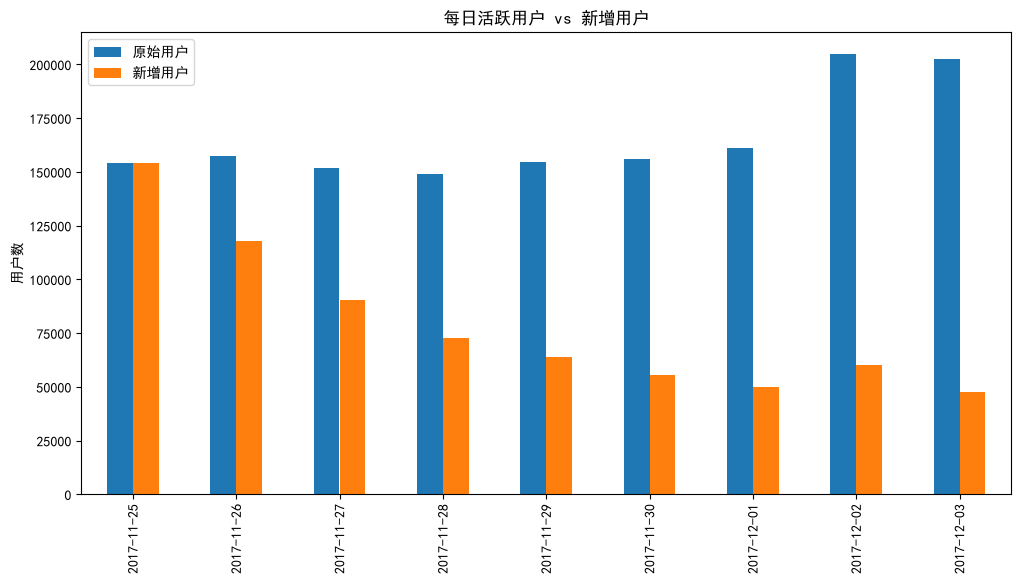

In [13]:
# 1.1 分析新用户（第一次出现的用户）：按天排序，找到每个用户的首次出现时间
user_first_touch = df.groupby('user_id')['datetime'].min().reset_index()
user_first_touch['first_date'] = user_first_touch['datetime'].dt.date
new_users_per_day = user_first_touch.groupby('first_date').size()

print("每日新增用户:")
print(new_users_per_day)

# 1.2 可视化新老用户对比：需要将新用户数据与DAU合并
plt.figure(figsize=(12, 6))

dau = df.groupby('date')['user_id'].nunique()
acquisition_df = pd.DataFrame({'原始用户': dau, '新增用户': new_users_per_day}).fillna(0)
acquisition_df.plot(kind='bar', figsize=(12,6))
plt.title('每日活跃用户 vs 新增用户')
plt.ylabel('用户数')
plt.show()

### 2.用户留存分析

分析目的：  
1.衡量用户粘性：计算次日留存率，评估产品对用户的持续吸引力  
2.定位流失节点：识别用户流失的关键时间点，为优化产品体验提供依据  
3.指导运营策略：根据留存率变化趋势，调整运营活动和推送策略

分析逻辑：  
1.留存定义：用户在注册/首次访问后的第N天仍然活跃的比例（通常计算次日留存、7日留存）  
2.以下分析采用次日留存：计算用户在第一次访问后的第二天是否仍有行为记录  
3.时间窗口：基于9天数据集，计算每日的次日留存率

          日期       留存率
0 2017-11-25  0.257445
1 2017-11-26  0.241628
2 2017-11-27  0.245072
3 2017-11-28  0.250336
4 2017-11-29  0.248476
5 2017-11-30  0.249446
6 2017-12-01  0.283129
7 2017-12-02  0.270274


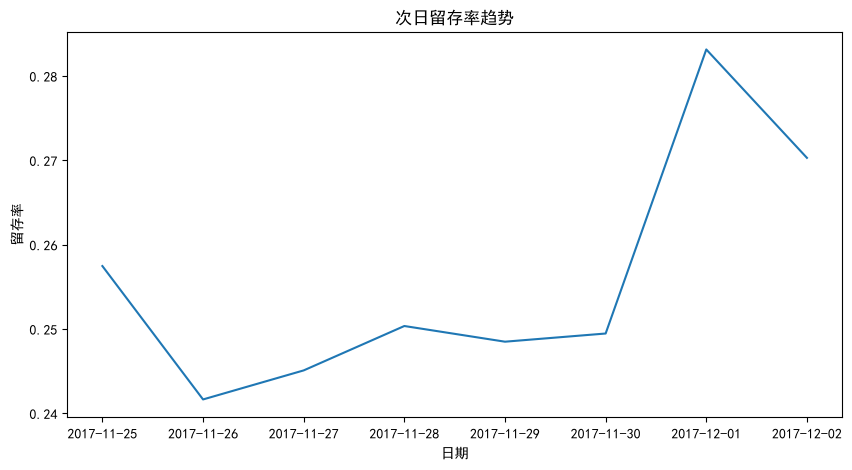

In [14]:
# 2.1 计算次日留存
df_date = df[['user_id', 'date']].drop_duplicates()
df_date['date'] = pd.to_datetime(df_date['date'])
df_date = df_date.sort_values('date')

# 获取所有日期
dates = sorted(df_date['date'].unique())
retention_rates = []

for i in range(len(dates)-1):
    cohort_date = dates[i]
    next_date = dates[i+1]
    
    # 当天的用户
    cohort_users = df_date[df_date['date'] == cohort_date]['user_id'].unique()
    # 次日仍活跃的用户
    retained_users = df_date[(df_date['date'] == next_date) & 
                            (df_date['user_id'].isin(cohort_users))]['user_id'].unique()
    
    retention_rate = len(retained_users) / len(cohort_users) if len(cohort_users) > 0 else 0
    retention_rates.append({'日期': cohort_date, '留存率': retention_rate})

retention_df = pd.DataFrame(retention_rates)
print(retention_df)

plt.figure(figsize=(10, 5))
sns.lineplot(data=retention_df, x='日期', y='留存率')
plt.title('次日留存率趋势')
plt.ylabel('留存率')
plt.show()

关键洞悉：  
周六留存25.74%，周日直接跌至全周期最低24.16%，工作日留存率较平缓，波动较小，12月1日（周五）留存率暴涨至28.3%，达到周期峰值  
策略建议：  
周五是运营活动投放的最优窗口期，转化留存效果远优于平时。可以在周五发放红包、满减券，并限时周末使用，引导用户次日回访，把新用户一次性浏览转化为跨天回访行为，解决周末留存率下降痛点


### 3.转化漏斗分析

分析目的：  
1.诊断转化瓶颈：量化用户从浏览到购买的每一步转化率，识别流失最严重的环节  
2.优化用户体验：针对转化率低的环节提出产品优化建议  
3.评估运营效果：为营销活动的投资回报率（ROI）计算提供基准数据

分析逻辑：  
1.漏斗层级：浏览(PV) → 收藏、加购(CART+FAV) → 购买(BUY)  
2.转化率计算：  
浏览→收藏、加购率 = (收藏+加购数) / 浏览数  
收藏、加购→购买率 = 购买数 / (收藏+加购数)  
整体转化率 = 购买数 / 浏览数

浏览 (PV): 1792891 (转化率: 100.00%)
收藏/加购 (CART+FAV): 168749 (转化率: 9.41%)
购买 (BUY): 40252 (转化率: 23.85%)
整体转化率: 2.25%


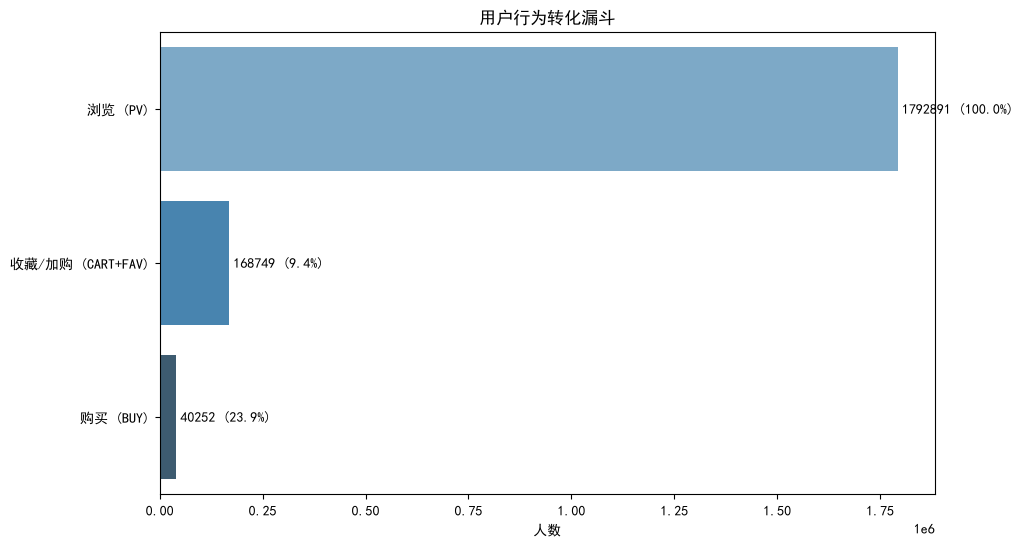

In [25]:
total_pv = len(df[df['behavior_type'] == 'pv'])
total_cart = len(df[df['behavior_type'] == 'cart'])
total_fav = len(df[df['behavior_type'] == 'fav'])
total_buy = len(df[df['behavior_type'] == 'buy'])

# 3.1 计算漏斗层级
steps = ['浏览 (PV)', '收藏/加购 (CART+FAV)', '购买 (BUY)']
values = [total_pv, total_cart + total_fav, total_buy]

# 3.2 计算转化率
conversion_rates = [100.0]
for i in range(1, len(values)):
    rate = (values[i] / values[i-1]) * 100
    conversion_rates.append(rate)

for step, val, rate in zip(steps, values, conversion_rates):
    print(f"{step}: {val} (转化率: {rate:.2f}%)")

total = total_buy / total_pv * 100
print(f"整体转化率: {total:.2f}%")

# 3.3 绘制漏斗图 (使用条形图模拟)
plt.figure(figsize=(10, 6))
sns.barplot(x=values, y=steps, palette='Blues_d')
plt.title('用户行为转化漏斗')
plt.xlabel('人数')

# 3.4 在条形上标注数值和转化率
for i, (val, rate) in enumerate(zip(values, conversion_rates)):
    plt.text(val + 10000, i, f"{val} ({rate:.1f}%)", va='center')
plt.show()

关键洞察:  
1.最大流失发生在"浏览→购买"环节，转化率仅2.25%，以及“浏览→收藏、加购”，转化率为9.41%  
2.中间环节：收藏、加购到购买的转化率为23.85%，有优化空间

策略建议：  
1.优化商品详情页，增加信任元素（评价、销量、保障）  
2.优化加购到购买的路径，减少支付流程的摩擦

### 4.品类分析

分析目的：  
1.识别爆款品类：找出销量最高的Top品类，为选品和库存管理提供依据  
2.发现潜力品类：识别转化率高但流量较小的品类，加大推广力度  
3.优化品类结构：平衡高流量低转化与高转化低流量品类的资源配置

分析逻辑：  
1.转化率分析：计算各品类的购买转化率 = 购买量 / 浏览量  
2.销量分析：按购买量排序，识别热销品类  
3.高意向分析：计算加购+收藏率，识别用户感兴趣但未购买的品类  
4.机会识别：交叉分析转化率与流量，寻找优化机会

Top 10 转化率品类:
behavior_type  item_category  conversion_rate  buy  pv
2301                 1712001         5.500000   11   2
1870                 1404020         3.777778   34   9
3526                 2611262         2.000000    2   1
4376                 3203956         2.000000    2   1
1393                 1030192         1.529412   26  17
5358                 3901193         1.071429   15  14
235                   180839         1.000000    1   1
408                   300775         1.000000    1   1
742                   556840         1.000000    1   1
924                   712478         1.000000    1   1


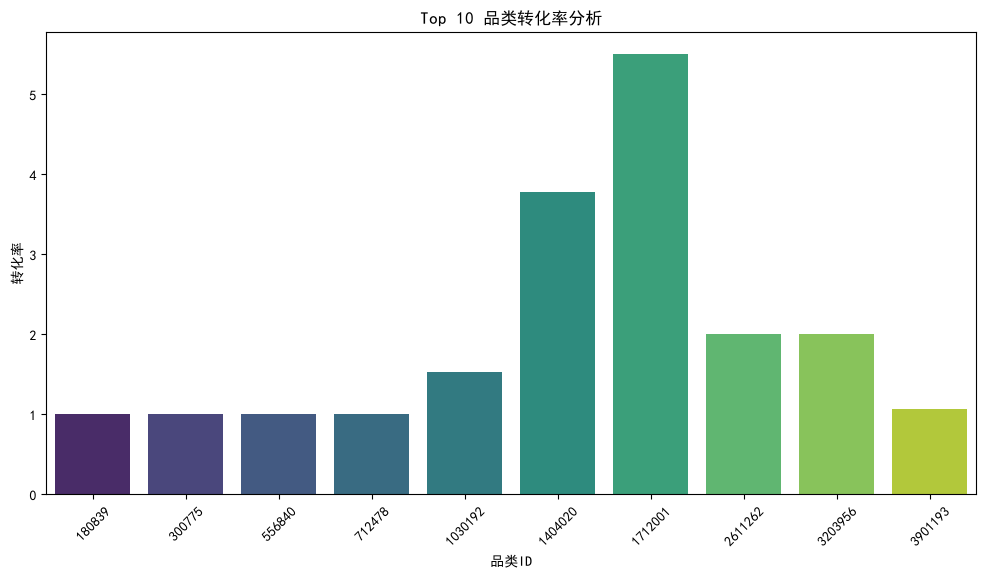


Top 10 销量品类:
behavior_type  item_category  buy
1958                 1464116  686
3710                 2735466  672
5669                 4145813  641
6477                 4756105  613
3924                 2885642  593
6548                 4801426  547
1322                  982926  469
3567                 2640118  383
5687                 4159072  371
5970                 4357323  332


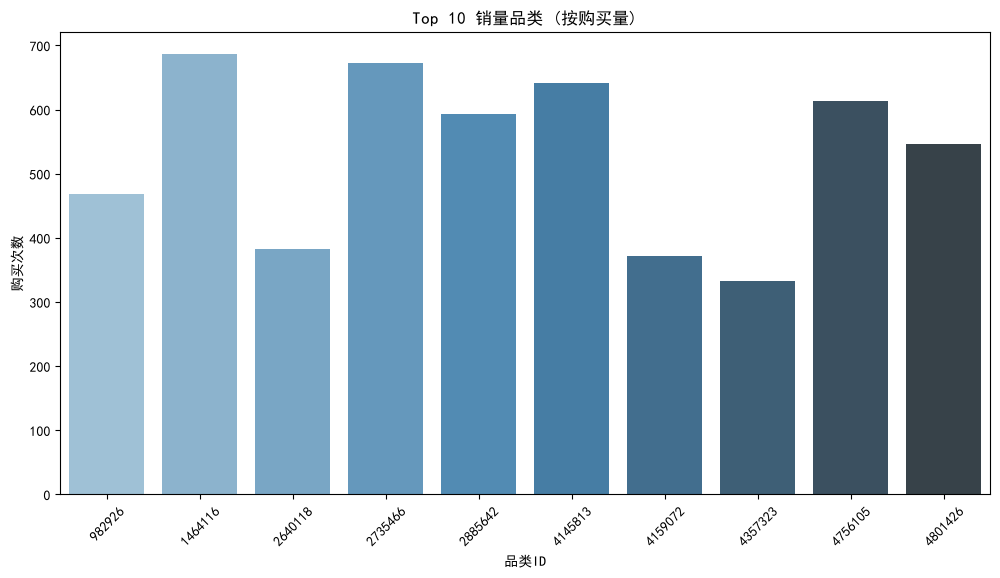

In [16]:
# 4.1 计算每个品类的详细行为
category_behavior = df.groupby(['item_category', 'behavior_type']).size().unstack(fill_value=0).reset_index()

# 检查列是否存在
if 'pv' not in category_behavior.columns:
    category_behavior['pv'] = 0
if 'buy' not in category_behavior.columns:
    category_behavior['buy'] = 0

# 4.2 计算转化率（避免除以0）
category_behavior['conversion_rate'] = category_behavior.apply(
    lambda row: row['buy'] / row['pv'] if row['pv'] > 0 else 0, axis=1
)

# 4.3 只保留有浏览记录的品类，避免 inf
category_behavior_filtered = category_behavior[category_behavior['pv'] > 0]

# 4.4 Top 10 转化率品类
top_conversion = category_behavior_filtered.nlargest(10, 'conversion_rate')
print("Top 10 转化率品类:")
print(top_conversion[['item_category', 'conversion_rate', 'buy', 'pv']])

# 4.5 可视化
plt.figure(figsize=(12, 6))
sns.barplot(data=top_conversion, x='item_category', y='conversion_rate', palette='viridis')
plt.title('Top 10 品类转化率分析')
plt.xlabel('品类ID')
plt.ylabel('转化率')
plt.xticks(rotation=45)
plt.show()

# 4.6 Top 10 销量品类（按购买量）
top_sales = category_behavior.nlargest(10, 'buy')
print("\nTop 10 销量品类:")
print(top_sales[['item_category', 'buy']])

plt.figure(figsize=(12, 6))
sns.barplot(data=top_sales, x='item_category', y='buy', palette='Blues_d')
plt.title('Top 10 销量品类 (按购买量)')
plt.xlabel('品类ID')
plt.ylabel('购买次数')
plt.xticks(rotation=45)
plt.show()

关键洞察：  
1.畅销品类：品类 1464116、2735466、4145813 购买量最高，是核心爆款  
2.高转化品类：部分小众品类转化率超过5%，值得增加曝光  
3.机会品类：存在高流量但低转化的品类，可优化商品详情页

策略建议：  
1.对畅销品类加大库存投入和流量倾斜  
2.对小众高转化品类进行精细化运营  
3.对高流量低转化品类进行A/B测试，优化转化路径

# 五、机器学习用户分层(RFM + K-Means)

分析目的：  
1.科学用户分层：突破传统人工规则的主观局限，使用机器学习自动识别用户群体  
2.精准营销：针对不同用户群体制定差异化的运营策略，提升ROI  
3.流失预警：识别"即将流失"的用户特征，提前采取挽回措施

分析逻辑：  
1.RFM模型（经典用户价值模型）：  
维度 含义 计算方式  
R (Recency)：最近一次购买距离现在的时间即天数 (分析基准日 - 最后购买日期)  
F (Frequency)：购买频率	（用户总购买次数）  
M (Monetary)：货币价值	（总行为数）

2.K-Means聚类流程：  
数据标准化：使用StandardScaler消除量纲差异  
确定K值：通过"肘部法则"和"轮廓系数"综合评估  
聚类执行：对标准化后的RFM特征进行聚类  
业务标注：根据各聚类中心的RFM均值赋予业务含义

In [17]:
! pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.18.0-cp313-cp313-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.23.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.23.0-py3-none-any.whl (458 kB)
Using cached scipy-1.18.0-cp313-cp313-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------

## 1.导入必要的库

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

## 2.构建RFM特征矩阵

In [19]:
# 2.1 确定分析基准日期
try:
    reference_date = df['datetime'].max()
except KeyError:
    # 如果 datetime 列不存在，尝试使用 'date' 列，或者重新生成 datetime
    print("⚠️ 警告: 'datetime' 列未找到，尝试使用 'date' 列。建议检查数据清洗流程。")
    # 尝试将 'date' 转换为 datetime 类型进行计算
    reference_date = pd.to_datetime(df['date']).max()

# 2.2 提取购买行为数据
buy_data = df[df['behavior_type'] == 'buy']

# 2.3 检查是否有购买数据，防止空值报错
if buy_data.empty:
    raise ValueError("数据集中没有找到购买行为 ('buy')，无法进行 RFM 分析。请检查数据过滤条件。")

# 2.4 计算 R (Recency) 和 F (Frequency)
r_and_f = buy_data.groupby('user_id').agg({
    'datetime': lambda x: (reference_date - x.max()).days,  # 最近购买天数
    'behavior_type': 'count'  # 购买次数
}).rename(columns={'datetime': 'R', 'behavior_type': 'F'})

# 2.5 计算 M (Monetary): 在此场景下用总行为数代替
total_behavior = df.groupby('user_id')['behavior_type'].count().rename('M')

# 2.6 合并得到完整的 RFM 数据框
rfm_df = pd.concat([r_and_f, total_behavior], axis=1, join='inner')

# 2.7 处理 R 为 0 的情况（当天购买），防止后续对数变换出错
rfm_df['R'] = rfm_df['R'].apply(lambda x: 1 if x == 0 else x)

# 2.8 检查合并后的数据
print(f"RFM数据形状: {rfm_df.shape}")
print(f"是否存在缺失值:\n{rfm_df.isnull().sum()}")
print(f"RFM数据预览:\n{rfm_df.head()}")

RFM数据形状: (38423, 3)
是否存在缺失值:
R    0
F    0
M    0
dtype: int64
RFM数据预览:
         R  F  M
user_id         
62       1  1  2
80       8  1  4
107      6  1  1
190      6  1  6
192      5  2  5


## 3.数据预处理与标准化

In [20]:
# 选择用于聚类的特征
features_for_clustering = ['R', 'F', 'M']
X = rfm_df[features_for_clustering]

# 检查特征矩阵是否为空
if X.empty:
    raise ValueError("特征矩阵为空，请检查数据清洗步骤。")

# 使用 StandardScaler 进行标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. K-Means 聚类

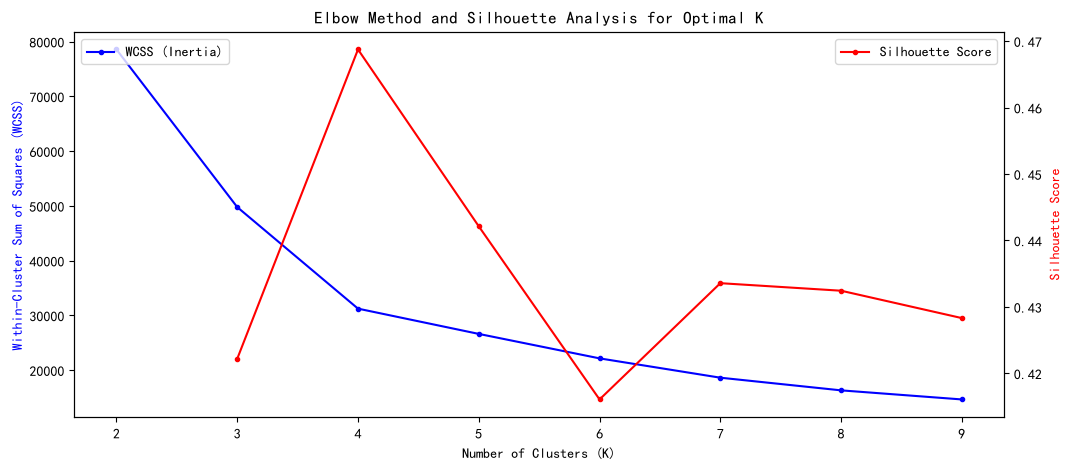

根据轮廓系数分析，选择最优聚类数量 K = 3


In [21]:
# 4.1. 确定最优聚类数量 
inertias = []
silhouette_scores = []
K_range = range(2, 10) # 从2到9个簇

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)
    if k > 1: # Silhouette Score requires at least 2 clusters
        score = silhouette_score(X_scaled, kmeans_temp.labels_)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(None)

# 4.2 可视化肘部法则和轮廓系数
fig, ax1 = plt.subplots(figsize=(12, 5))

ax2 = ax1.twinx()
line1 = ax1.plot(K_range, inertias, 'b.-', label='WCSS (Inertia)')
ax2.plot(K_range[1:], silhouette_scores[1:], 'r.-', label='Silhouette Score') # Start from k=2 for silhouette

ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)', color='b')
ax2.set_ylabel('Silhouette Score', color='r')
plt.title('Elbow Method and Silhouette Analysis for Optimal K')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

# 选择最优 K 值 (这里选择轮廓系数最高的 K，或者根据图表手动设定)
# 为了防止索引错误，这里写一个简单的逻辑：如果 silhouette_scores 为空，选 4
optimal_k = 4
if silhouette_scores:
    optimal_k = K_range[np.argmax(silhouette_scores) + 1] # +1 因为 silhouette_scores 从 k=2 开始
print(f"根据轮廓系数分析，选择最优聚类数量 K = {optimal_k}")

# 4.3 执行 K-Means 聚类
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# 4.4 将聚类结果添加回原始数据框
rfm_df['Cluster'] = cluster_labels


## 5.分析聚类结果与业务标签

In [22]:
# 查看每个簇的统计摘要
cluster_summary = rfm_df.groupby('Cluster')[['R', 'F', 'M']].agg(['mean', 'count']).round(2)
print("各聚类中心的RFM均值及用户数量:")
print(cluster_summary)

# 为每个聚类赋予业务含义
cluster_names = {}
for i in range(optimal_k):
    cluster_data = rfm_df[rfm_df['Cluster'] == i][['R', 'F', 'M']]
    avg_r = cluster_data['R'].mean()
    avg_f = cluster_data['F'].mean()
    avg_m = cluster_data['M'].mean()
    
    # 这里的命名是基于RFM的一般逻辑推断
    if avg_r < rfm_df['R'].quantile(0.25) and avg_f > rfm_df['F'].quantile(0.75):
        name = '高价值用户'
    elif avg_r < rfm_df['R'].quantile(0.25) and avg_f < rfm_df['F'].quantile(0.25):
        name = '新用户'
    elif avg_r > rfm_df['R'].quantile(0.75):
        name = '流失用户'
    else:
        name = '一般用户'
        
    cluster_names[i] = name

rfm_df['Cluster_Name'] = rfm_df['Cluster'].map(cluster_names)

各聚类中心的RFM均值及用户数量:
            R            F            M       
         mean  count  mean  count  mean  count
Cluster                                       
0        6.35  16264  1.00  16264  3.83  16264
1        2.06  20450  1.00  20450  3.25  20450
2        2.93   1709  2.07   1709  5.24   1709


## 6.生成用户分群报告

In [23]:
segment_report = rfm_df.groupby('Cluster_Name').agg({
    'R': ['mean', 'std'],
    'F': ['mean', 'std'],
    'M': ['mean', 'std'],
    'Cluster': 'count'
}).round(2)

segment_report.columns = ['Avg_R', 'Std_R', 'Avg_F', 'Std_F', 'Avg_M', 'Std_M', 'User_Count']
segment_report.sort_values(by='User_Count', ascending=False, inplace=True)

print("企业级用户分群报告:")
print(segment_report)


企业级用户分群报告:
              Avg_R  Std_R  Avg_F  Std_F  Avg_M  Std_M  User_Count
Cluster_Name                                                      
一般用户           2.13   1.26   1.08    0.3   3.41   2.38       22159
流失用户           6.35   1.21   1.00    0.0   3.83   2.71       16264


策略建议：

用户分层精细化运营：  
| 用户分层 | 特征 | 运营策略 |
| :------: | :------: | :------: |
| 流失用户（1.6万人） | R值高，近期无购买 | 召回短信 + 大额券，每月1次 |
| 一般用户（2.2万人） | 中等活跃，购买少 | 日常签到 + 任务系统，促活为主 |
| 高价值用户（待识别） | 高频高M | VIP客服 + 新品优先体验 + 生日礼包 |